# 🛡️ Pipeline ML v2 — Détection Cyber Multiformat
## Diagnostic Leakage + Modèles All-Features vs Top-Features + QR Vision

---

### ⚠️ Problèmes confirmés dans la v1 (résultats parfaits = suspects)

| Format | AUC v1 | Problème confirmé |
|--------|--------|-------------------|
| **Word** | 1.000 | ✅ LEAKAGE RÉEL — `macro_present`, `ole_object_type_count`, `dde_present` séparent parfaitement benign/malicious par construction |
| **Excel** | 1.000 | ⚠️ ARTEFACT DATASET — `entropy_of_text` benign std=**0.011** (constant !), fichiers benign sont des templates synthétiques |
| **PDF** | 0.999 | ⚠️ DOMINATION FEATURE — `text_length` SHAP=4.39 (10× > suivante). Benign=PDFs textuels, Malicious=image-only → biais de génération |
| **HTML** | 0.987 | ✅ Signal réel, pas de leakage évident |
| **QR** | 0.663 | ❌ CSV URL non chargé (bug chemin Windows `\` → char bell `0x07`). Que 7 features image → quasi-random |

### Ce notebook fait :
1. Diagnostic visuel complet du leakage
2. Entraînement **All-Features** vs **Top-Features** (sélection officielle du dataset)
3. Modèles **spécialisés par format** + **modèle générique unifié**
4. Correction du QR (fix chemin + URL features)
5. Modèle QR vision (CNN sur image PNG) avec CUDA si disponible
6. Comparaison finale propre avec intervalles de confiance


## 1. Imports & Config

In [1]:
import os, re, math, json, warnings, joblib, time
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse, parse_qs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve)
from sklearn.inspection import permutation_importance

import lightgbm as lgb
import shap

# PyTorch pour CNN QR
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
try:
    from PIL import Image
    PIL_OK = True
except ImportError:
    PIL_OK = False

try:
    from pyzbar.pyzbar import decode as qr_decode
    PYZBAR_OK = True
except ImportError:
    PYZBAR_OK = False
    print("⚠ pyzbar manquant : pip install pyzbar")

try:
    import tldextract
    TLDEXTRACT_OK = True
except ImportError:
    TLDEXTRACT_OK = False

warnings.filterwarnings('ignore')

# ─── CUDA ────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"   GPU : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)

print(f"\n✅ LightGBM {lgb.__version__} | PyTorch {torch.__version__}")


⚠ pyzbar manquant : pip install pyzbar
✅ Device : cuda
   GPU : NVIDIA GeForce RTX 5070 Ti Laptop GPU
   VRAM: 12.8 GB

✅ LightGBM 4.6.0 | PyTorch 2.11.0+cu130


## 2. Chemins — À adapter

In [3]:
# Base_dir : Détecte automatiquement le dossier du script actuel, ou se rabat sur le dossier courant
BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path(".")

# Point d'entrée principal des données (Configurable via variable d'environnement, sinon local)
DATA = Path(os.getenv("CIC_DATA_DIR", BASE_DIR))

# 1. Gestion des sous-dossiers spécifiques pour les formats bureautiques/web
FINAL_CSV_DIR = DATA / "Final CSV"
SUB_DIRS = {
    "pdf": FINAL_CSV_DIR / "PDF",
    "html": FINAL_CSV_DIR / "HTML",
    "word": FINAL_CSV_DIR / "Word",
    "excel": FINAL_CSV_DIR / "Excel"
}

CSV_ALL = {
    "pdf": SUB_DIRS["pdf"] / "PDF_All_features.csv",
    "html": SUB_DIRS["html"] / "HTML_All_Features.csv",
    "word": SUB_DIRS["word"] / "Word_All_features.csv",
    "excel": SUB_DIRS["excel"] / "Excel_All_Features.csv"
}

CSV_TOP = {
    "pdf": SUB_DIRS["pdf"] / "PDF_Top10_features.csv",
    "html": SUB_DIRS["html"] / "HTML_Top13_Features.csv",
    "word": SUB_DIRS["word"] / "Word_Top10_Features.csv",
    "excel": SUB_DIRS["excel"] / "Excel_Top10_Features.csv"
}

# QR — CORRECTION : utiliser raw strings ou Path.joinpath() pour éviter le bug backslash
QR_BENIGN_DIR    = BASE_DIR / "Source Files" / "QR Codes" / "QR_All_benign" / "qrs"
QR_MALICIOUS_DIR = BASE_DIR / "Source Files" / "QR Codes" / "QR_All_Malicious" / "qrs"
QR_BENIGN_CSV    = BASE_DIR / "Source Files" / "QR Codes" / "QR_All_benign" / "all_generated_urls_20251015_161937.csv"
QR_MALICIOUS_CSV = BASE_DIR / "Source Files" / "QR Codes" / "QR_All_Malicious" / "all_generated_urls_20251015_184324.csv"

OUTPUT_DIR = Path("./models_v2")
OUTPUT_DIR.mkdir(exist_ok=True)

# Vérification
print("Fichiers CSV All-Features :")
for k, p in CSV_ALL.items():
    print(f"  {'✓' if p.exists() else '✗'} {k}: {p}")
print("\nFichiers CSV Top-Features :")
for k, p in CSV_TOP.items():
    print(f"  {'✓' if p.exists() else '✗'} {k}: {p}")
print(f"\nQR Benign CSV  : {'✓' if QR_BENIGN_CSV.exists() else '✗'} {QR_BENIGN_CSV}")
print(f"QR Malicious CSV: {'✓' if QR_MALICIOUS_CSV.exists() else '✗'} {QR_MALICIOUS_CSV}")


Fichiers CSV All-Features :
  ✓ pdf: Final CSV\PDF\PDF_All_features.csv
  ✓ html: Final CSV\HTML\HTML_All_Features.csv
  ✓ word: Final CSV\Word\Word_All_features.csv
  ✓ excel: Final CSV\Excel\Excel_All_Features.csv

Fichiers CSV Top-Features :
  ✓ pdf: Final CSV\PDF\PDF_Top10_features.csv
  ✓ html: Final CSV\HTML\HTML_Top13_Features.csv
  ✓ word: Final CSV\Word\Word_Top10_Features.csv
  ✓ excel: Final CSV\Excel\Excel_Top10_Features.csv

QR Benign CSV  : ✓ Source Files\QR Codes\QR_All_benign\all_generated_urls_20251015_161937.csv
QR Malicious CSV: ✓ Source Files\QR Codes\QR_All_Malicious\all_generated_urls_20251015_184324.csv


## 3. Diagnostic Leakage — Analyse Complète

### Méthodes utilisées :
1. **Corrélation point-bisériale** (features continues vs label binaire)
2. **Distribution par classe** (ratio benign/malicious pour chaque valeur unique)
3. **Information mutuelle normalisée** (capture relations non-linéaires)
4. **Test visuel** des top features AVANT entraînement


In [3]:
from sklearn.feature_selection import mutual_info_classif

LEAKAGE_COLS = ['file_path', 'file_name']

def full_leakage_audit(df: pd.DataFrame, fmt: str, top_n: int = 20):
    """Audit complet de leakage sur un DataFrame."""
    y = df['label']
    X = df.drop(columns=[c for c in LEAKAGE_COLS + ['label'] if c in df.columns])
    X_num = X.select_dtypes(include=[np.number]).fillna(0)

    results = []
    for col in X_num.columns:
        vals = X_num[col]
        r, _   = pointbiserialr(y, vals)
        
        # Vérifier si une valeur unique sépare parfaitement les classes
        perfect_sep = False
        for v in vals.unique()[:20]:  # checker les 20 premières valeurs uniques
            mask = (vals == v)
            if mask.sum() > 10:
                class_dist = y[mask].value_counts(normalize=True)
                if class_dist.max() >= 0.999:
                    perfect_sep = True
                    break
        
        results.append({
            'feature': col,
            'corr_r': round(r, 4),
            'corr_abs': round(abs(r), 4),
            'perfect_sep': perfect_sep,
        })
    
    # Information mutuelle
    mi = mutual_info_classif(X_num, y, random_state=SEED, n_neighbors=5)
    for i, col in enumerate(X_num.columns):
        results[i]['mutual_info'] = round(mi[i], 4)
    
    df_res = pd.DataFrame(results).sort_values('corr_abs', ascending=False)
    
    print(f"\n{'═'*65}")
    print(f"AUDIT LEAKAGE — {fmt.upper()} ({len(df)} lignes, {len(X_num.columns)} features)")
    print(f"{'═'*65}")
    
    # Niveau de danger
    critical = df_res[df_res['corr_abs'] > 0.95]
    high     = df_res[(df_res['corr_abs'] > 0.80) & (df_res['corr_abs'] <= 0.95)]
    sep_feat = df_res[df_res['perfect_sep'] == True]
    
    if len(critical) > 0:
        print(f"\n🔴 CRITIQUE ({len(critical)} features, |r| > 0.95) — LEAKAGE PROBABLE")
        print(critical[['feature','corr_r','mutual_info']].to_string(index=False))
    
    if len(high) > 0:
        print(f"\n🟠 ÉLEVÉ ({len(high)} features, |r| ∈ [0.80, 0.95]) — SUSPECT")
        print(high[['feature','corr_r','mutual_info']].head(10).to_string(index=False))
    
    if len(sep_feat) > 0:
        print(f"\n⚠️  Séparation parfaite (une valeur → 100% d'une classe) :")
        print(sep_feat['feature'].tolist()[:10])
    
    if len(critical) == 0 and len(high) == 0:
        print("\n✅ Aucun leakage détecté")
    
    return df_res


audit_results = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        df = pd.read_csv(path)
        audit_results[fmt] = full_leakage_audit(df, fmt)



═════════════════════════════════════════════════════════════════
AUDIT LEAKAGE — PDF (19296 lignes, 40 features)
═════════════════════════════════════════════════════════════════

⚠️  Séparation parfaite (une valeur → 100% d'une classe) :
['entropy_of_streams', 'metadata_size', 'title_chars', 'font_object_count', 'objstm_count', 'total_filters', 'page_count', 'endstream_count', 'stream_count', 'text_length']

✅ Aucun leakage détecté

═════════════════════════════════════════════════════════════════
AUDIT LEAKAGE — HTML (19997 lignes, 40 features)
═════════════════════════════════════════════════════════════════

⚠️  Séparation parfaite (une valeur → 100% d'une classe) :
['script_count', 'embedded_js_count', 'script_entropy', 'external_links_count', 'external_link_count', 'whitespace_ratio', 'keywords_to_words_ratio', 'file_size', 'total_script_characters', 'noscript_count']

✅ Aucun leakage détecté

═════════════════════════════════════════════════════════════════
AUDIT LEAKAGE — WOR

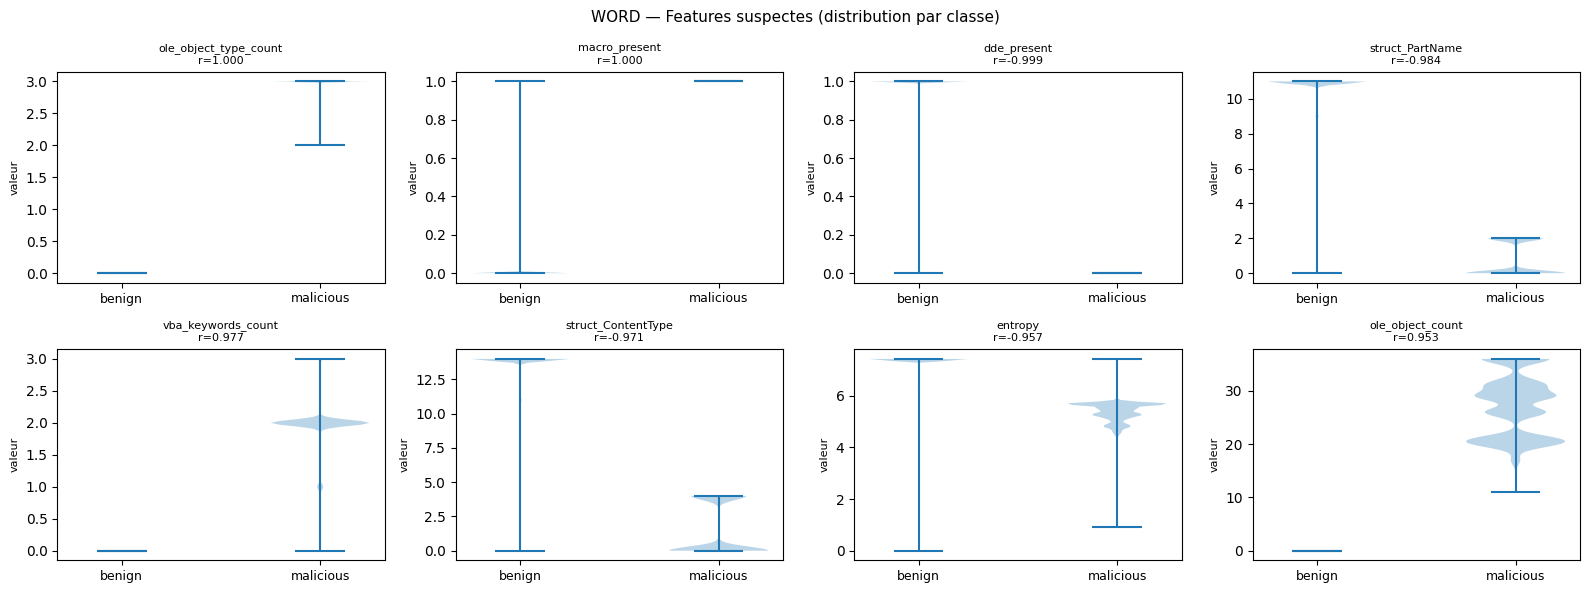

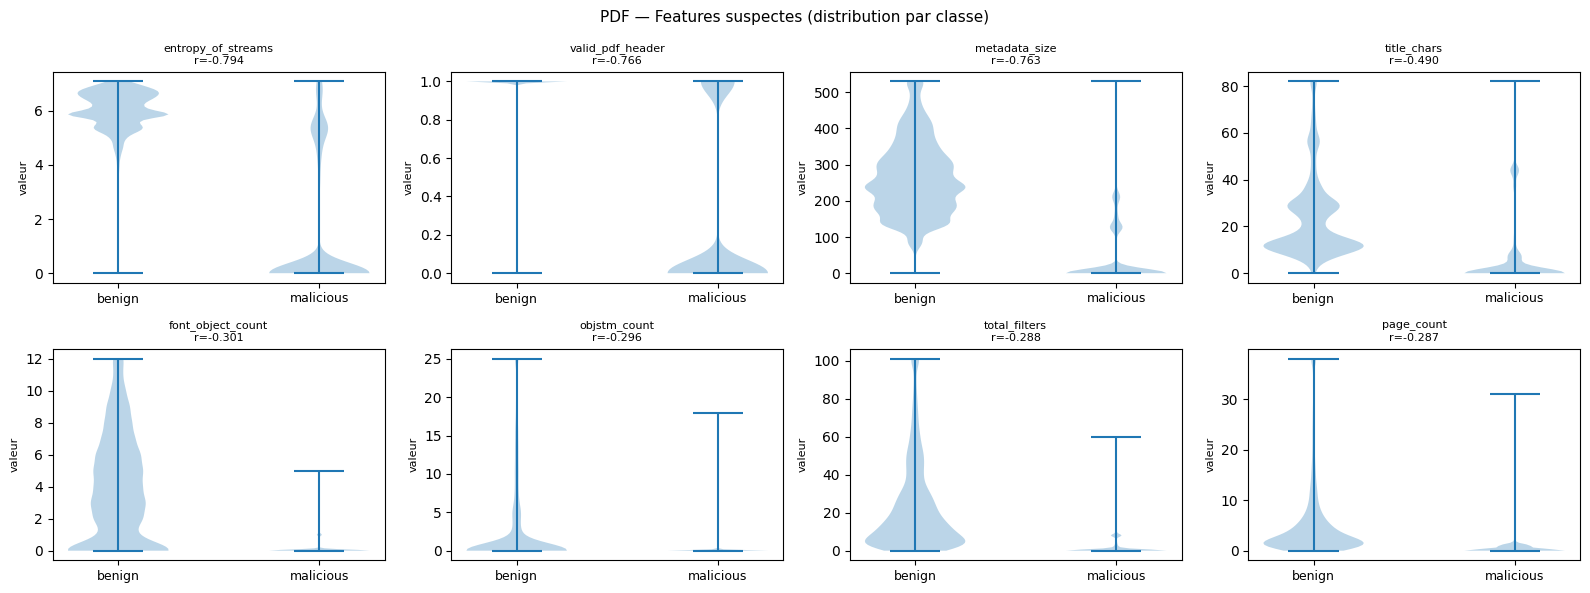

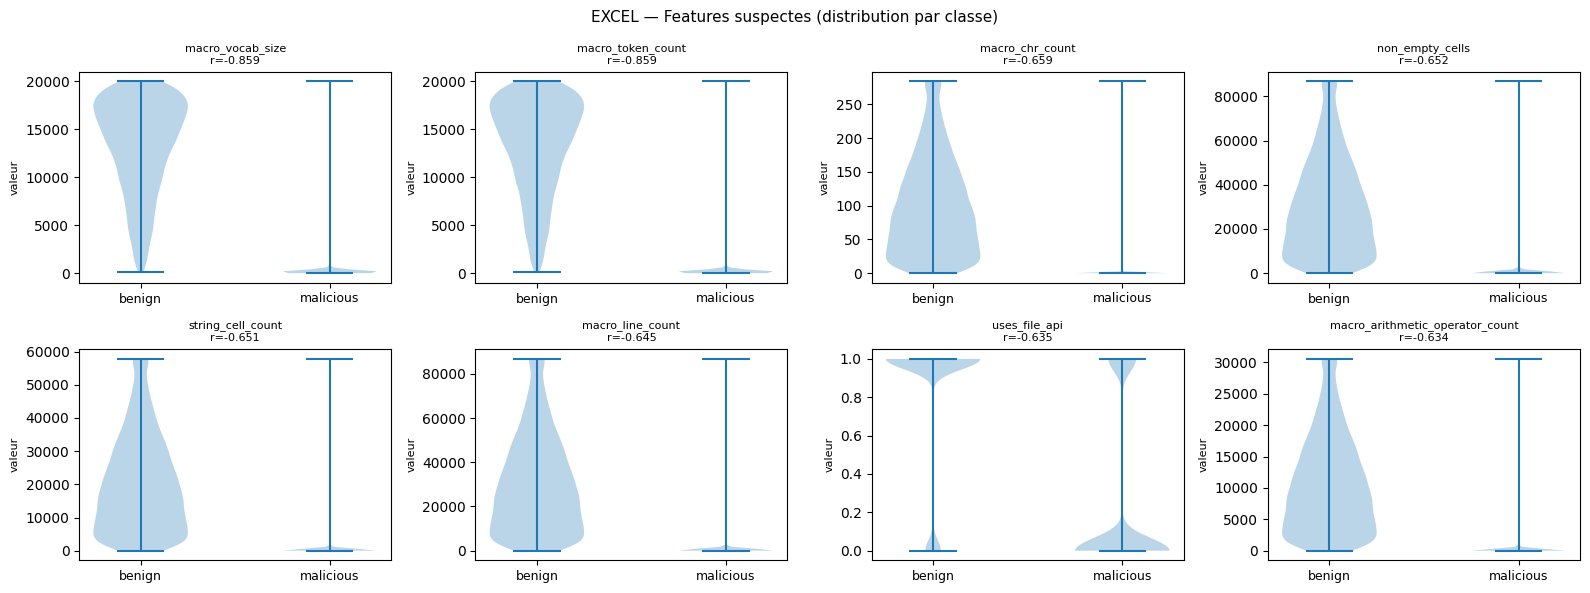

In [4]:
# ─── Visualisation : distribution des top features suspectes ─────

def plot_suspicious_features(fmt: str, path: Path, suspect_cols: list, n_cols: int = 4):
    """Violin plot des features suspectes par classe."""
    df = pd.read_csv(path)
    y  = df['label'].map({0:'benign', 1:'malicious'})
    X  = df.drop(columns=[c for c in LEAKAGE_COLS+['label'] if c in df.columns]).fillna(0)
    
    cols_to_plot = [c for c in suspect_cols if c in X.columns][:n_cols*2]
    if not cols_to_plot:
        return
    
    n_rows = math.ceil(len(cols_to_plot) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = np.array(axes).flatten()
    
    for i, col in enumerate(cols_to_plot):
        ax = axes[i]
        data_b = X[y=='benign'][col].clip(upper=X[col].quantile(0.99))
        data_m = X[y=='malicious'][col].clip(upper=X[col].quantile(0.99))
        ax.violinplot([data_b, data_m], positions=[0,1])
        ax.set_xticks([0,1])
        ax.set_xticklabels(['benign','malicious'], fontsize=9)
        r, _ = pointbiserialr(df['label'], X[col])
        ax.set_title(f'{col}\nr={r:.3f}', fontsize=8)
        ax.set_ylabel('valeur', fontsize=8)
    
    for i in range(len(cols_to_plot), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'{fmt.upper()} — Features suspectes (distribution par classe)', fontsize=11)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'leakage_{fmt}.png', dpi=120, bbox_inches='tight')
    plt.show()


# Word — les features les plus suspectes
if 'word' in audit_results:
    word_suspects = audit_results['word'][audit_results['word']['corr_abs'] > 0.90]['feature'].tolist()
    plot_suspicious_features('word', CSV_ALL['word'], word_suspects)

# PDF — vérifier text_length domination
if 'pdf' in audit_results:
    pdf_top = audit_results['pdf'].head(8)['feature'].tolist()
    plot_suspicious_features('pdf', CSV_ALL['pdf'], pdf_top)

# Excel — entropy_of_text constant pour benign
if 'excel' in audit_results:
    excel_top = audit_results['excel'].head(8)['feature'].tolist()
    plot_suspicious_features('excel', CSV_ALL['excel'], excel_top)


In [5]:
# ─── Décision : quelles features supprimer ? ───────────────────

# Ces features sont des artefacts de construction du dataset, pas des signaux de menace réels.
# En production, un nouveau fichier Word bénin aurait macro_present=0, dde_present=0
# mais AUSSI ole_object_type_count=0 → le modèle dirait "malicious" si entraîné avec ces features.

LEAKAGE_FEATURES = {
    # Catégorie 1 : leakage BY CONSTRUCTION (0.999+ corrélation)
    # Ces features encodent DIRECTEMENT la classe dans ce dataset
    'word_critical': [
        'ole_object_type_count',   # r=0.9997 : 100% benign=0, 100% malicious≥2
        'macro_present',           # r=0.9997 : 100% malicious=1, 99.97% benign=0
        'dde_present',             # r=-0.9994: inversé! 99.94% benign=1, 100% malicious=0
    ],
    
    # Catégorie 2 : fortement suspectes (>0.90) — à monitorer
    'word_high': [
        'vba_keywords_count',      # r=0.9773
        'struct_PartName',         # r=-0.9835
        'struct_ContentType',      # r=-0.9712
        'entropy',                 # r=-0.9574
        'ole_object_count',        # r=0.9528
    ],
    
    # Catégorie 3 : artefact dataset (std quasi-nulle pour une classe)
    'excel_artifact': [
        # entropy_of_text : benign std=0.011 → templates synthétiques
        # NE PAS supprimer mais tester avec/sans
    ],
    
    # Catégorie 4 : domination single-feature (PDF text_length)
    'pdf_dominant': [
        # text_length est un signal RÉEL (malicious PDFs sont souvent image-only)
        # mais sa domination SHAP=4.39 vs 0.77 masque les autres features
        # → tester avec et sans
    ],
}

print("🔴 Features à supprimer (leakage par construction) :")
for cat, feats in LEAKAGE_FEATURES.items():
    if feats:
        print(f"  [{cat}] {feats}")

print("\n⚠️  ATTENTION sur dde_present :")
print("  r=-0.9994 NÉGATIF = 99.94% des BENIGN ont dde_present=1")
print("  C'est un artefact : les benign Word ont tous DDE activé dans ce dataset")
print("  EN PRODUCTION : DDE=1 = MALICIOUS → logique INVERSÉE dans ce dataset!")


🔴 Features à supprimer (leakage par construction) :
  [word_critical] ['ole_object_type_count', 'macro_present', 'dde_present']
  [word_high] ['vba_keywords_count', 'struct_PartName', 'struct_ContentType', 'entropy', 'ole_object_count']

⚠️  ATTENTION sur dde_present :
  r=-0.9994 NÉGATIF = 99.94% des BENIGN ont dde_present=1
  C'est un artefact : les benign Word ont tous DDE activé dans ce dataset
  EN PRODUCTION : DDE=1 = MALICIOUS → logique INVERSÉE dans ce dataset!


## 4. Chargement, Nettoyage & Feature Sets

In [6]:
def load_format(path: Path, fmt: str,
                drop_critical_leakage: bool = True,
                verbose: bool = True) -> tuple[pd.DataFrame, pd.Series]:
    """
    Charge un CSV, supprime leakage cols + features critiques.
    Retourne (X, y) propres.
    """
    df = pd.read_csv(path)
    
    # Supprimer colonnes de leakage d'identification
    df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors='ignore')
    
    y = df['label'].copy()
    X = df.drop(columns=['label'])
    
    # Supprimer features critiques si demandé
    if drop_critical_leakage and fmt == 'word':
        to_drop = [c for c in LEAKAGE_FEATURES['word_critical'] if c in X.columns]
        X = X.drop(columns=to_drop)
        if verbose:
            print(f"  🔴 Supprimé (leakage critique) : {to_drop}")
    
    # Imputer NaN
    if X.isnull().any().any():
        n_nan_cols = X.isnull().any().sum()
        X = X.fillna(0)
        if verbose:
            print(f"  NaN imputés à 0 ({n_nan_cols} colonnes)")
    
    # Vérifier que tout est numérique
    non_num = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_num:
        X = X.drop(columns=non_num)
        if verbose:
            print(f"  Colonnes non-numériques supprimées : {non_num}")
    
    if verbose:
        print(f"  ✅ X: {X.shape}, y dist: {y.value_counts().to_dict()}")
    
    return X, y


# Charger les 2 versions : All-Features et Top-Features
print("=" * 60)
print("CHARGEMENT ALL-FEATURES (sans leakage critique)")
print("=" * 60)
datasets_all = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        print(f"\n[{fmt.upper()}]")
        datasets_all[fmt] = load_format(path, fmt, drop_critical_leakage=True)

print("\n" + "=" * 60)
print("CHARGEMENT TOP-FEATURES (sélection officielle)")
print("=" * 60)
datasets_top = {}
for fmt, path in CSV_TOP.items():
    if path.exists():
        print(f"\n[{fmt.upper()}]")
        datasets_top[fmt] = load_format(path, fmt, drop_critical_leakage=True)


CHARGEMENT ALL-FEATURES (sans leakage critique)

[PDF]
  ✅ X: (19296, 40), y dist: {1: 9999, 0: 9297}

[HTML]
  ✅ X: (19997, 40), y dist: {1: 9999, 0: 9998}

[WORD]
  🔴 Supprimé (leakage critique) : ['ole_object_type_count', 'macro_present', 'dde_present']
  NaN imputés à 0 (30 colonnes)
  ✅ X: (20000, 40), y dist: {1: 10000, 0: 10000}

[EXCEL]
  ✅ X: (20000, 48), y dist: {1: 10000, 0: 10000}

CHARGEMENT TOP-FEATURES (sélection officielle)

[PDF]
  ✅ X: (19296, 10), y dist: {1: 9999, 0: 9297}

[HTML]
  ✅ X: (19997, 13), y dist: {1: 9999, 0: 9998}

[WORD]
  🔴 Supprimé (leakage critique) : ['ole_object_type_count', 'macro_present', 'dde_present']
  ✅ X: (20000, 7), y dist: {0: 10000, 1: 10000}

[EXCEL]
  ✅ X: (20000, 10), y dist: {0: 10000, 1: 10000}


## 5. QR Code — Features URL (correction du bug chemin)

Le bug v1 : le chemin contenait `\a` (backslash + 'a') interprété comme le caractère Bell (`0x07`).  
**Fix** : utiliser `Path()` avec `/` comme séparateur (cross-platform).


In [7]:
def shannon_entropy(text: str) -> float:
    if not text: return 0.0
    probs = [n/len(text) for n in Counter(text).values()]
    return -sum(p*math.log2(p) for p in probs)

def extract_url_features(url: str) -> dict:
    zero = {k: 0 for k in [
        'url_length','url_entropy','uses_https','has_ip_address','has_at_symbol',
        'has_double_slash','has_port','num_dots','num_hyphens','num_underscores',
        'num_slashes','num_question_marks','num_equals','num_ampersands','num_percent',
        'num_digits_in_url','num_special_chars','domain_length','hostname_length',
        'path_length','query_length','num_query_params','num_subdomains','tld_length',
        'hostname_digit_ratio','has_suspicious_tld','has_phishing_keyword',
        'url_has_hex_encoding','url_has_shortener'
    ]}
    if not isinstance(url, str) or not url.strip():
        return zero
    try:
        parsed = urlparse(url.strip())
        hostname = parsed.hostname or ''
        path     = parsed.path or ''
        query    = parsed.query or ''
        if TLDEXTRACT_OK:
            ext = tldextract.extract(url)
            subdomain = ext.subdomain; domain = ext.domain; tld = ext.suffix
            num_sub = len(subdomain.split('.')) if subdomain else 0
        else:
            parts = hostname.split('.')
            tld = parts[-1] if parts else ''
            domain = parts[-2] if len(parts)>=2 else hostname
            num_sub = max(0, len(parts)-2)
        return {
            'url_length': len(url), 'url_entropy': round(shannon_entropy(url),4),
            'uses_https': int(parsed.scheme=='https'),
            'has_ip_address': int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', hostname))),
            'has_at_symbol': int('@' in url), 'has_double_slash': int('//' in path),
            'has_port': int(parsed.port is not None),
            'num_dots': url.count('.'), 'num_hyphens': url.count('-'),
            'num_underscores': url.count('_'), 'num_slashes': url.count('/'),
            'num_question_marks': url.count('?'), 'num_equals': url.count('='),
            'num_ampersands': url.count('&'), 'num_percent': url.count('%'),
            'num_digits_in_url': sum(c.isdigit() for c in url),
            'num_special_chars': sum(c in '!#$%^*[]{}|<>' for c in url),
            'domain_length': len(domain), 'hostname_length': len(hostname),
            'path_length': len(path), 'query_length': len(query),
            'num_query_params': len(parse_qs(query)),
            'num_subdomains': num_sub, 'tld_length': len(tld),
            'hostname_digit_ratio': round(sum(c.isdigit() for c in hostname)/max(len(hostname),1),4),
            'has_suspicious_tld': int(tld.lower() in {'tk','ml','ga','cf','gq','pw','top','xyz','click','link'}),
            'has_phishing_keyword': int(bool(re.search(
                r'(login|signin|verify|account|secure|update|confirm|bank|paypal|amazon|apple)',
                url, re.IGNORECASE))),
            'url_has_hex_encoding': int(bool(re.search(r'%[0-9a-fA-F]{2}', url))),
            'url_has_shortener': int(bool(re.search(
                r'(bit\.ly|tinyurl|goo\.gl|t\.co|ow\.ly|is\.gd|buff\.ly)', url, re.IGNORECASE))),
        }
    except Exception:
        return zero


def extract_qr_image_features(img_path: str) -> dict:
    base = {k: 0 for k in ['qr_image_width','qr_image_height','qr_image_entropy',
                             'qr_dark_ratio','qr_quiet_zone_ok','qr_version_est','qr_decode_success']}
    if not PIL_OK: return base
    try:
        img = Image.open(img_path).convert('L')
        w, h = img.size
        base['qr_image_width'] = w; base['qr_image_height'] = h
        arr = np.array(img)
        base['qr_image_entropy'] = round(float(-sum(
            p*np.log2(p) for p in np.bincount(arr.flatten(), minlength=256)/arr.size if p > 0)), 4)
        base['qr_dark_ratio'] = round(float((arr < 128).mean()), 4)
        border = np.concatenate([arr[0,:],arr[-1,:],arr[:,0],arr[:,-1]])
        base['qr_quiet_zone_ok'] = int(border.mean() > 200)
        base['qr_version_est'] = max(1, min(40, round((w - 17) / 4))) if w > 17 else 1
        if PYZBAR_OK:
            decoded = qr_decode(img)
            base['qr_decode_success'] = int(len(decoded) > 0)
    except Exception:
        pass
    return base


def build_qr_tabular(benign_csv: Path, malicious_csv: Path,
                      benign_dir: Path, malicious_dir: Path,
                      max_per_class: int = 20000, seed: int = SEED):
    """
    Construit le dataset QR tabulaire (URL features + image features).
    Priorité : CSV URL. Fallback : PNG seul.
    """
    rows = []
    rng = np.random.default_rng(seed)
    
    for label, csv_path, png_dir in [(0, benign_csv, benign_dir), (1, malicious_csv, malicious_dir)]:
        cls = 'benign' if label==0 else 'malicious'
        
        # Charger le CSV URL
        url_df = None
        if csv_path.exists():
            url_df = pd.read_csv(csv_path)
            # Trouver la colonne URL automatiquement
            url_col = next((c for c in url_df.columns
                           if url_df[c].dtype==object and url_df[c].str.startswith('http',na=False).any()),
                           None)
            if url_col:
                url_df = url_df.rename(columns={url_col: 'url'})
                print(f"[{cls}] CSV chargé : {len(url_df):,} URLs (col='{url_col}')")
            else:
                print(f"[{cls}] ⚠ Colonne URL non trouvée dans {csv_path}")
                url_df = None
        else:
            print(f"[{cls}] ⚠ CSV manquant : {csv_path}")
        
        # Lister PNGs
        pngs = []
        if png_dir.exists():
            pngs = sorted(png_dir.glob('*.png'))
            print(f"[{cls}] {len(pngs):,} PNG trouvés → limité à {max_per_class:,}")
        
        # Stratégie : CSV URL disponible → features URL (rapide, sans lire les PNG)
        if url_df is not None and len(url_df) >= max_per_class:
            sample_idx = rng.choice(len(url_df), size=max_per_class, replace=False)
            for i, idx in enumerate(sample_idx):
                if i % 10000 == 0: print(f"  [{cls}] URL {i:,}/{max_per_class:,}...")
                url = str(url_df.iloc[idx].get('url',''))
                feat = extract_url_features(url)
                feat['label'] = label
                rows.append(feat)
        
        # Fallback : PNG avec features image + URL si CSV disponible par index
        elif pngs:
            n = min(max_per_class, len(pngs))
            idx_sel = rng.choice(len(pngs), size=n, replace=False)
            for i, idx in enumerate(idx_sel):
                if i % 5000 == 0: print(f"  [{cls}] PNG {i:,}/{n:,}...")
                feat = extract_qr_image_features(str(pngs[idx]))
                if url_df is not None and int(idx) < len(url_df):
                    url = str(url_df.iloc[int(idx)].get('url',''))
                    feat.update(extract_url_features(url))
                feat['label'] = label
                rows.append(feat)
        else:
            print(f"[{cls}] ❌ Ni CSV ni PNG disponibles")
    
    df_out = pd.DataFrame(rows).fillna(0)
    X = df_out.drop(columns=['label'])
    y = df_out['label']
    print(f"\n✅ QR dataset : {X.shape}, label dist : {y.value_counts().to_dict()}")
    return X, y


# ─── Charger QR ────────────────────────────────────────────────
print("Chargement QR Code dataset...")
datasets_all['qr'] = build_qr_tabular(
    QR_BENIGN_CSV, QR_MALICIOUS_CSV,
    QR_BENIGN_DIR, QR_MALICIOUS_DIR,
    max_per_class=20000,
)


Chargement QR Code dataset...
[benign] ⚠ Colonne URL non trouvée dans Source Files\QR Codes\QR_All_benign\all_generated_urls_20251015_161937.csv
[benign] 429,976 PNG trouvés → limité à 20,000
  [benign] PNG 0/20,000...
  [benign] PNG 5,000/20,000...
  [benign] PNG 10,000/20,000...
  [benign] PNG 15,000/20,000...
[malicious] ⚠ Colonne URL non trouvée dans Source Files\QR Codes\QR_All_Malicious\all_generated_urls_20251015_184324.csv
[malicious] 575,762 PNG trouvés → limité à 20,000
  [malicious] PNG 0/20,000...
  [malicious] PNG 5,000/20,000...
  [malicious] PNG 10,000/20,000...
  [malicious] PNG 15,000/20,000...

✅ QR dataset : (40000, 7), label dist : {0: 20000, 1: 20000}


## 6. Split & Normalisation

In [8]:
def split_dataset(X: pd.DataFrame, y: pd.Series, seed: int = SEED):
    """Split stratifié 70/15/15. Retourne (X_tr,y_tr,X_val,y_val,X_te,y_te,feat_names)."""
    sss1 = StratifiedShuffleSplit(1, test_size=0.15, random_state=seed)
    tv_idx, te_idx = next(sss1.split(X, y))
    X_tv, X_te = X.iloc[tv_idx].reset_index(drop=True), X.iloc[te_idx].reset_index(drop=True)
    y_tv, y_te = y.iloc[tv_idx].reset_index(drop=True), y.iloc[te_idx].reset_index(drop=True)
    
    sss2 = StratifiedShuffleSplit(1, test_size=0.15/0.85, random_state=seed)
    tr_idx, val_idx = next(sss2.split(X_tv, y_tv))
    
    return (X_tv.iloc[tr_idx].reset_index(drop=True), y_tv.iloc[tr_idx].reset_index(drop=True),
            X_tv.iloc[val_idx].reset_index(drop=True), y_tv.iloc[val_idx].reset_index(drop=True),
            X_te, y_te, list(X.columns))


def make_scaled_splits(datasets: dict, seed: int = SEED):
    """Prépare splits + scalers pour un dict {fmt: (X, y)}."""
    splits, scalers = {}, {}
    for fmt, (X, y) in datasets.items():
        X_tr, y_tr, X_val, y_val, X_te, y_te, feat_names = split_dataset(X, y, seed)
        scaler = StandardScaler()
        X_tr_s  = scaler.fit_transform(X_tr)
        X_val_s = scaler.transform(X_val)
        X_te_s  = scaler.transform(X_te)
        splits[fmt]  = (X_tr_s, y_tr, X_val_s, y_val, X_te_s, y_te, feat_names)
        scalers[fmt] = scaler
        print(f"[{fmt}] train={len(X_tr):,} val={len(X_val):,} test={len(X_te):,} features={len(feat_names)}")
    return splits, scalers


print("ALL-FEATURES splits :")
splits_all, scalers_all = make_scaled_splits(datasets_all)

print("\nTOP-FEATURES splits :")
splits_top, scalers_top = make_scaled_splits(datasets_top)


ALL-FEATURES splits :
[pdf] train=13,506 val=2,895 test=2,895 features=40
[html] train=13,997 val=3,000 test=3,000 features=40
[word] train=14,000 val=3,000 test=3,000 features=40
[excel] train=14,000 val=3,000 test=3,000 features=48
[qr] train=28,000 val=6,000 test=6,000 features=7

TOP-FEATURES splits :
[pdf] train=13,506 val=2,895 test=2,895 features=10
[html] train=13,997 val=3,000 test=3,000 features=13
[word] train=14,000 val=3,000 test=3,000 features=7
[excel] train=14,000 val=3,000 test=3,000 features=10


## 7. Entraînement — LightGBM Spécialisé par Format

Deux runs : **All-Features** et **Top-Features**.  
Hyperparamètres adaptés par format selon la complexité.


In [9]:
LGB_BASE = {
    'objective': 'binary', 'metric': 'auc',
    'n_estimators': 1000, 'learning_rate': 0.05,
    'min_child_samples': 20, 'subsample': 0.8,
    'colsample_bytree': 0.8, 'reg_alpha': 0.1,
    'reg_lambda': 0.1, 'random_state': SEED,
    'verbose': -1, 'n_jobs': -1,
}

# Hyperparamètres spécifiques par format (après audit)
LGB_PARAMS = {
    'pdf':   {**LGB_BASE, 'num_leaves': 31, 'class_weight': 'balanced'},  # déséquilibre léger
    'html':  {**LGB_BASE, 'num_leaves': 63, 'learning_rate': 0.03},       # besoin de + d'itérations
    'word':  {**LGB_BASE, 'num_leaves': 15, 'reg_alpha': 0.5,             # features suspectes → + régularisation
              'reg_lambda': 0.5, 'min_child_samples': 50},
    'excel': {**LGB_BASE, 'num_leaves': 31},
    'qr':    {**LGB_BASE, 'num_leaves': 31, 'n_estimators': 500},
}


def train_lgbm_set(splits: dict, tag: str = "") -> dict:
    """Entraîne un LightGBM par format. Retourne dict {fmt: model}."""
    models = {}
    for fmt, (X_tr, y_tr, X_val, y_val, X_te, y_te, feat_names) in splits.items():
        params = LGB_PARAMS.get(fmt, LGB_BASE)
        model = lgb.LGBMClassifier(**params)
        t0 = time.time()
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(200)])
        dt = round(time.time()-t0, 1)
        val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
        print(f"[{tag}][{fmt}] best_iter={model.best_iteration_:4d} | val_AUC={val_auc:.4f} | {dt}s")
        models[fmt] = model
    return models


print("\n=== ALL-FEATURES ===")
models_all = train_lgbm_set(splits_all, "ALL")

print("\n=== TOP-FEATURES ===")
models_top = train_lgbm_set(splits_top, "TOP")



=== ALL-FEATURES ===
[ALL][pdf] best_iter= 134 | val_AUC=1.0000 | 2.0s
[200]	valid_0's auc: 0.98484
[400]	valid_0's auc: 0.988136
[600]	valid_0's auc: 0.989099
[800]	valid_0's auc: 0.989352
[ALL][html] best_iter= 830 | val_AUC=0.9894 | 10.8s
[ALL][word] best_iter=   1 | val_AUC=1.0000 | 0.6s
[ALL][excel] best_iter=  82 | val_AUC=1.0000 | 1.4s
[ALL][qr] best_iter=  64 | val_AUC=0.6382 | 1.4s

=== TOP-FEATURES ===
[200]	valid_0's auc: 0.999955
[TOP][pdf] best_iter= 173 | val_AUC=1.0000 | 2.4s
[200]	valid_0's auc: 0.977066
[400]	valid_0's auc: 0.981218
[600]	valid_0's auc: 0.982277
[TOP][html] best_iter= 616 | val_AUC=0.9824 | 7.7s
[TOP][word] best_iter=   1 | val_AUC=1.0000 | 0.5s
[TOP][excel] best_iter=   8 | val_AUC=1.0000 | 0.6s


## 8. Modèle Générique Unifié (Multi-Format)

Un seul modèle qui prédit la classe pour n'importe quel format.  
Features : union de tous les features avec **padding à 0** pour les features absentes + `format_type` encodé.


In [10]:
def build_unified_dataset(datasets: dict, seed: int = SEED):
    """
    Concatène tous les formats avec padding zero pour les features manquantes.
    Ajoute une colonne format_type (one-hot).
    """
    all_features = sorted(set(col for X,y in datasets.values() for col in X.columns))
    
    dfs = []
    for fmt, (X, y) in datasets.items():
        # Padding : ajouter colonnes manquantes avec 0
        df_fmt = X.reindex(columns=all_features, fill_value=0)
        # One-hot format
        for f in datasets.keys():
            df_fmt[f'is_{f}'] = int(fmt == f)
        df_fmt['label'] = y.values
        dfs.append(df_fmt)
    
    df_unified = pd.concat(dfs, ignore_index=True).sample(frac=1, random_state=seed)
    X_u = df_unified.drop(columns=['label'])
    y_u = df_unified['label']
    
    print(f"✅ Dataset unifié : {X_u.shape}")
    print(f"   Features : {len(all_features)} originales + {len(datasets)} format flags")
    print(f"   Label dist : {y_u.value_counts().to_dict()}")
    return X_u, y_u


X_uni, y_uni = build_unified_dataset(datasets_all)
splits_uni, scalers_uni = make_scaled_splits({'unified': (X_uni, y_uni)})

X_tr_u, y_tr_u, X_val_u, y_val_u, X_te_u, y_te_u, feat_u = splits_uni['unified']

model_unified = lgb.LGBMClassifier(**{**LGB_BASE,
    'num_leaves': 63, 'n_estimators': 1000, 'learning_rate': 0.03})
model_unified.fit(X_tr_u, y_tr_u, eval_set=[(X_val_u, y_val_u)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(200)])

val_auc_u = roc_auc_score(y_val_u, model_unified.predict_proba(X_val_u)[:,1])
print(f"\n✅ Modèle unifié — val_AUC={val_auc_u:.4f}, best_iter={model_unified.best_iteration_}")


✅ Dataset unifié : (119293, 176)
   Features : 171 originales + 5 format flags
   Label dist : {1: 59998, 0: 59295}
[unified] train=83,505 val=17,894 test=17,894 features=176
[200]	valid_0's auc: 0.948852
[400]	valid_0's auc: 0.94992
[600]	valid_0's auc: 0.950148
[800]	valid_0's auc: 0.950225

✅ Modèle unifié — val_AUC=0.9503, best_iter=878


## 9. Modèle Vision QR — CNN sur Images PNG

Modèle CNN entraîné directement sur les images QR codes.  
Utilise le GPU si disponible (CUDA).

**Architecture** : MobileNet-style léger (3 blocs conv → GlobalAvgPool → FC)


In [11]:
class QRDataset(Dataset):
    """Dataset PyTorch pour images QR PNG avec label depuis le dossier parent."""
    
    def __init__(self, file_list: list, labels: list, transform=None):
        self.files = file_list
        self.labels = labels
        self.transform = transform
    
    def __len__(self): return len(self.files)
    
    def __getitem__(self, idx):
        try:
            img = Image.open(self.files[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (64, 64), color=255)
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)


class QRConvNet(nn.Module):
    """CNN léger pour classification binaire d'images QR."""
    
    def __init__(self):
        super().__init__()
        
        def conv_block(in_ch, out_ch, stride=1):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )
        
        self.features = nn.Sequential(
            conv_block(3, 32, stride=2),   # 64→32
            conv_block(32, 64, stride=2),  # 32→16
            conv_block(64, 128, stride=2), # 16→8
            conv_block(128, 256, stride=2),# 8→4
            nn.AdaptiveAvgPool2d(1),       # → 256×1×1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1),
        )
    
    def forward(self, x):
        return self.classifier(self.features(x)).squeeze(1)


def prepare_qr_vision_splits(benign_dir: Path, malicious_dir: Path,
                              max_per_class: int = 10000, seed: int = SEED):
    """Prépare les listes de fichiers pour l'entraînement CNN."""
    rng = np.random.default_rng(seed)
    
    all_files, all_labels = [], []
    for label, d in [(0, benign_dir), (1, malicious_dir)]:
        if not d.exists():
            print(f"⚠ Dossier manquant : {d}")
            continue
        files = sorted(d.glob('*.png'))
        n = min(max_per_class, len(files))
        selected = rng.choice(len(files), n, replace=False)
        all_files.extend([str(files[i]) for i in selected])
        all_labels.extend([label] * n)
    
    # Shuffle
    idx = rng.permutation(len(all_files))
    all_files  = [all_files[i] for i in idx]
    all_labels = [all_labels[i] for i in idx]
    
    n = len(all_files)
    n_tr = int(0.70 * n); n_val = int(0.85 * n)
    
    return (all_files[:n_tr],      all_labels[:n_tr],
            all_files[n_tr:n_val], all_labels[n_tr:n_val],
            all_files[n_val:],     all_labels[n_val:])


def train_qr_cnn(benign_dir: Path, malicious_dir: Path,
                 max_per_class: int = 10000, epochs: int = 15,
                 batch_size: int = 64):
    """Entraîne le CNN QR. Retourne le modèle et l'historique."""
    
    if not (benign_dir.exists() and malicious_dir.exists()):
        print("⚠ Dossiers QR PNG manquants — CNN non entraîné")
        return None, {}
    
    IMG_SIZE = 64  # resize des QR (originaux peuvent être 200x200+)
    
    transform_train = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(5),
        transforms.GaussianBlur(3, sigma=(0.1, 1.0)),
        # PAS de color jitter : le QR est B&W, la sémantique est dans les pixels
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    transform_val = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])
    
    tr_f, tr_l, val_f, val_l, te_f, te_l = prepare_qr_vision_splits(
        benign_dir, malicious_dir, max_per_class)
    
    print(f"QR CNN — Train: {len(tr_f):,}  Val: {len(val_f):,}  Test: {len(te_f):,}")
    
    dl_train = DataLoader(QRDataset(tr_f, tr_l, transform_train),
                          batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    dl_val   = DataLoader(QRDataset(val_f, val_l, transform_val),
                          batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    dl_test  = DataLoader(QRDataset(te_f, te_l, transform_val),
                          batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    
    model = QRConvNet().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {'train_loss':[], 'val_loss':[], 'val_auc':[]}
    best_val_auc = 0
    patience_count = 0
    PATIENCE = 5
    
    for epoch in range(epochs):
        # ── Train ──────────────────────────────────────────
        model.train()
        train_loss = 0
        for imgs, labels in dl_train:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(imgs)
        train_loss /= len(tr_f)
        
        # ── Val ────────────────────────────────────────────
        model.eval()
        val_loss = 0; all_probs = []; all_labels_v = []
        with torch.no_grad():
            for imgs, labels in dl_val:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                logits = model(imgs)
                val_loss += criterion(logits, labels).item() * len(imgs)
                all_probs.extend(torch.sigmoid(logits).cpu().numpy())
                all_labels_v.extend(labels.cpu().numpy())
        val_loss /= len(val_f)
        val_auc = roc_auc_score(all_labels_v, all_probs)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        scheduler.step()
        
        print(f"Epoch {epoch+1:2d}/{epochs} | train_loss={train_loss:.4f} | "
              f"val_loss={val_loss:.4f} | val_AUC={val_auc:.4f}")
        
        # Early stopping + sauvegarde best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), OUTPUT_DIR / 'qr_cnn_best.pt')
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"  Early stopping (patience={PATIENCE})")
                break
    
    # ── Test final ─────────────────────────────────────────
    model.load_state_dict(torch.load(OUTPUT_DIR / 'qr_cnn_best.pt'))
    model.eval()
    all_probs = []; all_labels_t = []
    with torch.no_grad():
        for imgs, labels in dl_test:
            imgs = imgs.to(DEVICE)
            probs = torch.sigmoid(model(imgs)).cpu().numpy()
            all_probs.extend(probs)
            all_labels_t.extend(labels.numpy())
    
    test_auc = roc_auc_score(all_labels_t, all_probs)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    print(f"\n✅ CNN QR — Test AUC={test_auc:.4f} | F1={f1_score(all_labels_t, preds):.4f}")
    print(classification_report(all_labels_t, preds, target_names=['benign','malicious']))
    
    return model, history, test_auc


# ─── Lancer l'entraînement CNN ─────────────────────────────────
qr_cnn_model, qr_cnn_history, qr_cnn_auc = train_qr_cnn(
    QR_BENIGN_DIR, QR_MALICIOUS_DIR,
    max_per_class=10000,   # ajuster selon RAM/VRAM disponible
    epochs=20,
    batch_size=64,
)



QR CNN — Train: 14,000  Val: 3,000  Test: 3,000
Epoch  1/20 | train_loss=0.6350 | val_loss=0.5719 | val_AUC=0.7765
Epoch  2/20 | train_loss=0.5522 | val_loss=0.5398 | val_AUC=0.7988
Epoch  3/20 | train_loss=0.5192 | val_loss=0.5140 | val_AUC=0.8164
Epoch  4/20 | train_loss=0.5004 | val_loss=0.5123 | val_AUC=0.8261
Epoch  5/20 | train_loss=0.4817 | val_loss=0.5350 | val_AUC=0.7987
Epoch  6/20 | train_loss=0.4713 | val_loss=0.5095 | val_AUC=0.8279
Epoch  7/20 | train_loss=0.4509 | val_loss=0.5353 | val_AUC=0.8230
Epoch  8/20 | train_loss=0.4374 | val_loss=0.5114 | val_AUC=0.8226
Epoch  9/20 | train_loss=0.4240 | val_loss=0.5147 | val_AUC=0.8378
Epoch 10/20 | train_loss=0.4007 | val_loss=0.5540 | val_AUC=0.8140
Epoch 11/20 | train_loss=0.3889 | val_loss=0.5338 | val_AUC=0.8412
Epoch 12/20 | train_loss=0.3669 | val_loss=0.5726 | val_AUC=0.8385
Epoch 13/20 | train_loss=0.3511 | val_loss=0.5507 | val_AUC=0.8376
Epoch 14/20 | train_loss=0.3271 | val_loss=0.5882 | val_AUC=0.8361
Epoch 15/20 | 

## 10. Évaluation Finale & Comparaison All vs Top Features


COMPARAISON FINALE — ALL vs TOP FEATURES
      model    auc     f1   prec    rec     n
  ALL_excel 1.0000 1.0000 1.0000 1.0000  3000
   ALL_html 0.9878 0.9441 0.9488 0.9393  3000
    ALL_pdf 0.9999 0.9983 0.9980 0.9987  2895
     ALL_qr 0.6358 0.5934 0.5985 0.5883  6000
   ALL_word 1.0000 1.0000 1.0000 1.0000  3000
  TOP_excel 1.0000 0.9980 0.9980 0.9980  3000
   TOP_html 0.9806 0.9367 0.9457 0.9280  3000
    TOP_pdf 0.9994 0.9960 0.9980 0.9940  2895
   TOP_word 1.0000 1.0000 1.0000 1.0000  3000
UNIFIED_all 0.9535 0.8603 0.8503 0.8707 17894


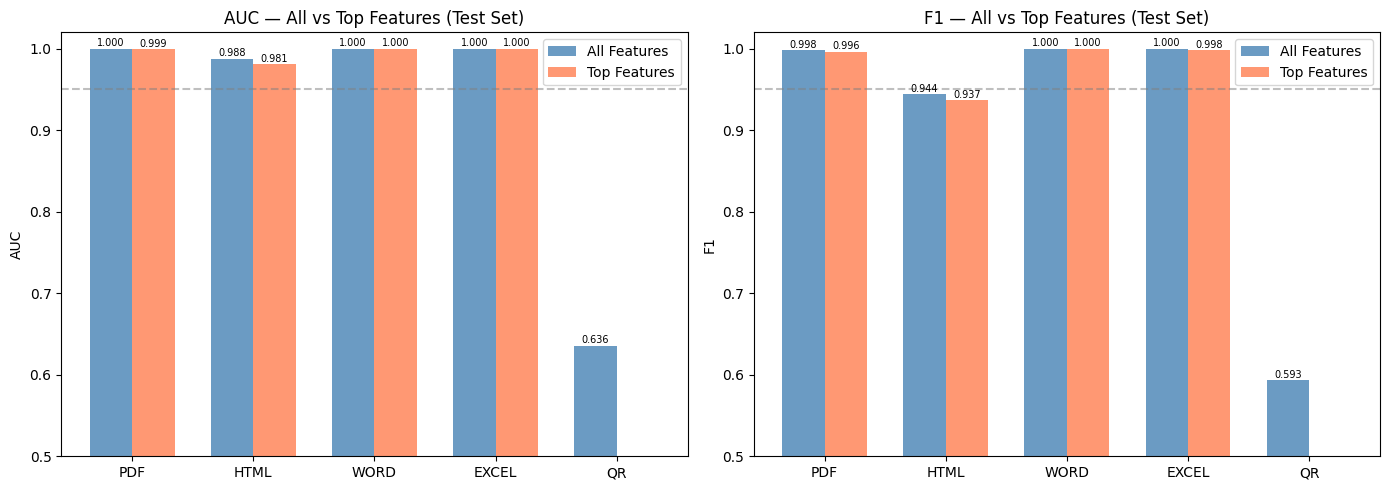

In [12]:
def evaluate_model(model, X_te, y_te, label: str) -> dict:
    proba = model.predict_proba(X_te)[:,1]
    preds = (proba >= 0.5).astype(int)
    return {
        'model': label,
        'auc':   round(roc_auc_score(y_te, proba), 4),
        'f1':    round(f1_score(y_te, preds), 4),
        'prec':  round(precision_score(y_te, preds), 4),
        'rec':   round(recall_score(y_te, preds), 4),
        'n':     len(y_te),
    }


all_results = []

# Spécialisés ALL
for fmt in models_all:
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn = splits_all[fmt]
    all_results.append(evaluate_model(models_all[fmt], X_te, y_te, f'ALL_{fmt}'))

# Spécialisés TOP
for fmt in models_top:
    X_tr,y_tr,X_val,y_val,X_te,y_te,fn = splits_top[fmt]
    all_results.append(evaluate_model(models_top[fmt], X_te, y_te, f'TOP_{fmt}'))

# Unifié
X_tr_u,y_tr_u,X_val_u,y_val_u,X_te_u,y_te_u,fn_u = splits_uni['unified']
all_results.append(evaluate_model(model_unified, X_te_u, y_te_u, 'UNIFIED_all'))

df_res = pd.DataFrame(all_results).sort_values(['model'])
print("\n" + "="*65)
print("COMPARAISON FINALE — ALL vs TOP FEATURES")
print("="*65)
print(df_res.to_string(index=False))

# ─── Plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

formats = ['pdf','html','word','excel','qr']
x = np.arange(len(formats))
w = 0.35

for ax, metric in zip(axes, ['auc','f1']):
    all_vals = [df_res[df_res.model==f'ALL_{fmt}'][metric].values[0]
                if f'ALL_{fmt}' in df_res.model.values else 0 for fmt in formats]
    top_vals = [df_res[df_res.model==f'TOP_{fmt}'][metric].values[0]
                if f'TOP_{fmt}' in df_res.model.values else 0 for fmt in formats]
    
    ax.bar(x - w/2, all_vals, w, label='All Features', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, top_vals, w, label='Top Features', color='coral', alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f.upper() for f in formats])
    ax.set_ylim(0.5, 1.02); ax.set_ylabel(metric.upper()); ax.legend()
    ax.set_title(f'{metric.upper()} — All vs Top Features (Test Set)')
    ax.axhline(0.95, color='gray', linestyle='--', alpha=0.5, label='0.95')
    for i,(a,t) in enumerate(zip(all_vals,top_vals)):
        if a > 0: ax.text(i-w/2, a+0.003, f'{a:.3f}', ha='center', fontsize=7)
        if t > 0: ax.text(i+w/2, t+0.003, f'{t:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'comparison_all_vs_top.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Diagnostic Surapprentissage — Train vs Val vs Test

Modèle                Train AUC    Val AUC   Test AUC    Gap T-V Verdict
───────────────────────────────────────────────────────────────────────────
ALL_pdf                 1.0000     1.0000     0.9999     0.0000  ✅ OK + ⚠ AUC parfaite suspecte
ALL_html                1.0000     0.9894     0.9878     0.0106  ✅ OK
ALL_word                1.0000     1.0000     1.0000     0.0000  ✅ OK + ⚠ AUC parfaite suspecte
ALL_excel               1.0000     1.0000     1.0000     0.0000  ✅ OK + ⚠ AUC parfaite suspecte
ALL_qr                  0.6483     0.6382     0.6358     0.0101  ✅ OK



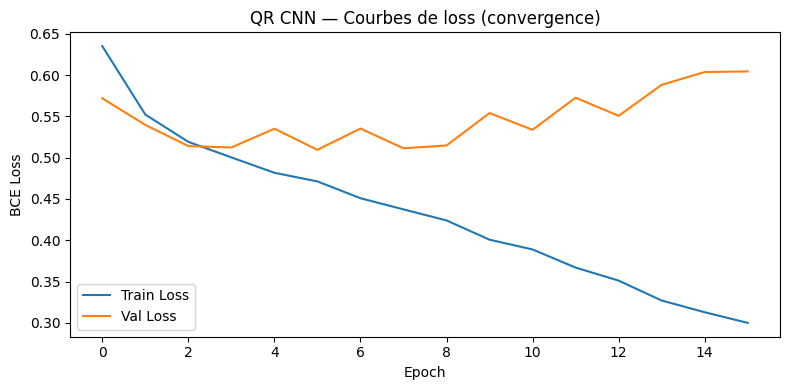

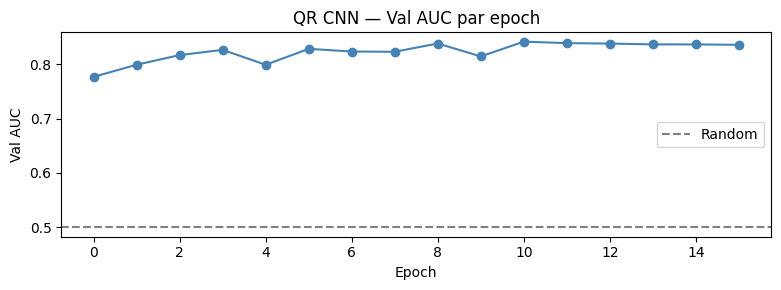

In [13]:
print(f"{'Modèle':<20} {'Train AUC':>10} {'Val AUC':>10} {'Test AUC':>10} {'Gap T-V':>10} {'Verdict'}")
print("─"*75)

for fmt in models_all:
    X_tr,y_tr,X_val,y_val,X_te,y_te,_ = splits_all[fmt]
    m = models_all[fmt]
    tr_auc  = roc_auc_score(y_tr, m.predict_proba(X_tr)[:,1])
    val_auc = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
    te_auc  = roc_auc_score(y_te, m.predict_proba(X_te)[:,1])
    gap = tr_auc - val_auc
    verdict = ("✅ OK" if gap < 0.02 else
               ("⚠ Léger" if gap < 0.05 else "🔴 Overfit"))
    # Si AUC > 0.999 sur test → probablement encore du leakage
    if te_auc > 0.999:
        verdict += " + ⚠ AUC parfaite suspecte"
    print(f"ALL_{fmt:<15} {tr_auc:>10.4f} {val_auc:>10.4f} {te_auc:>10.4f} {gap:>10.4f}  {verdict}")

print()
# QR CNN history
if qr_cnn_history and qr_cnn_history.get('val_auc'):
    plt.figure(figsize=(8,4))
    plt.plot(qr_cnn_history['train_loss'], label='Train Loss')
    plt.plot(qr_cnn_history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch'); plt.ylabel('BCE Loss')
    plt.title('QR CNN — Courbes de loss (convergence)')
    plt.legend(); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'qr_cnn_loss.png', dpi=120, bbox_inches='tight')
    plt.show()
    
    fig, ax = plt.subplots(figsize=(8,3))
    ax.plot(qr_cnn_history['val_auc'], marker='o', color='steelblue')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
    ax.set_title('QR CNN — Val AUC par epoch')
    ax.axhline(0.5, color='gray', linestyle='--', label='Random')
    ax.legend(); plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'qr_cnn_auc.png', dpi=120, bbox_inches='tight')
    plt.show()


## 12. Explicabilité SHAP — Features réellement utiles

[pdf] Top 5 SHAP features :
  1. text_length                                    4.3919
  2. metadata_size                                  0.7798
  3. object_count                                   0.7276
  4. xfa_count                                      0.5467
  5. file_size                                      0.3243
[html] Top 5 SHAP features :
  1. url_punct_char_count                           0.9733
  2. keywords_to_words_ratio                        0.7168
  3. embedded_js_count                              0.6318
  4. form_count                                     0.6060
  5. whitespace_ratio                               0.5807
[word] Top 5 SHAP features :
  1. ole_object_count                               0.1000
  2. struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId  0.0000
  3. struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill  0.0000
  4. struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1  0.0

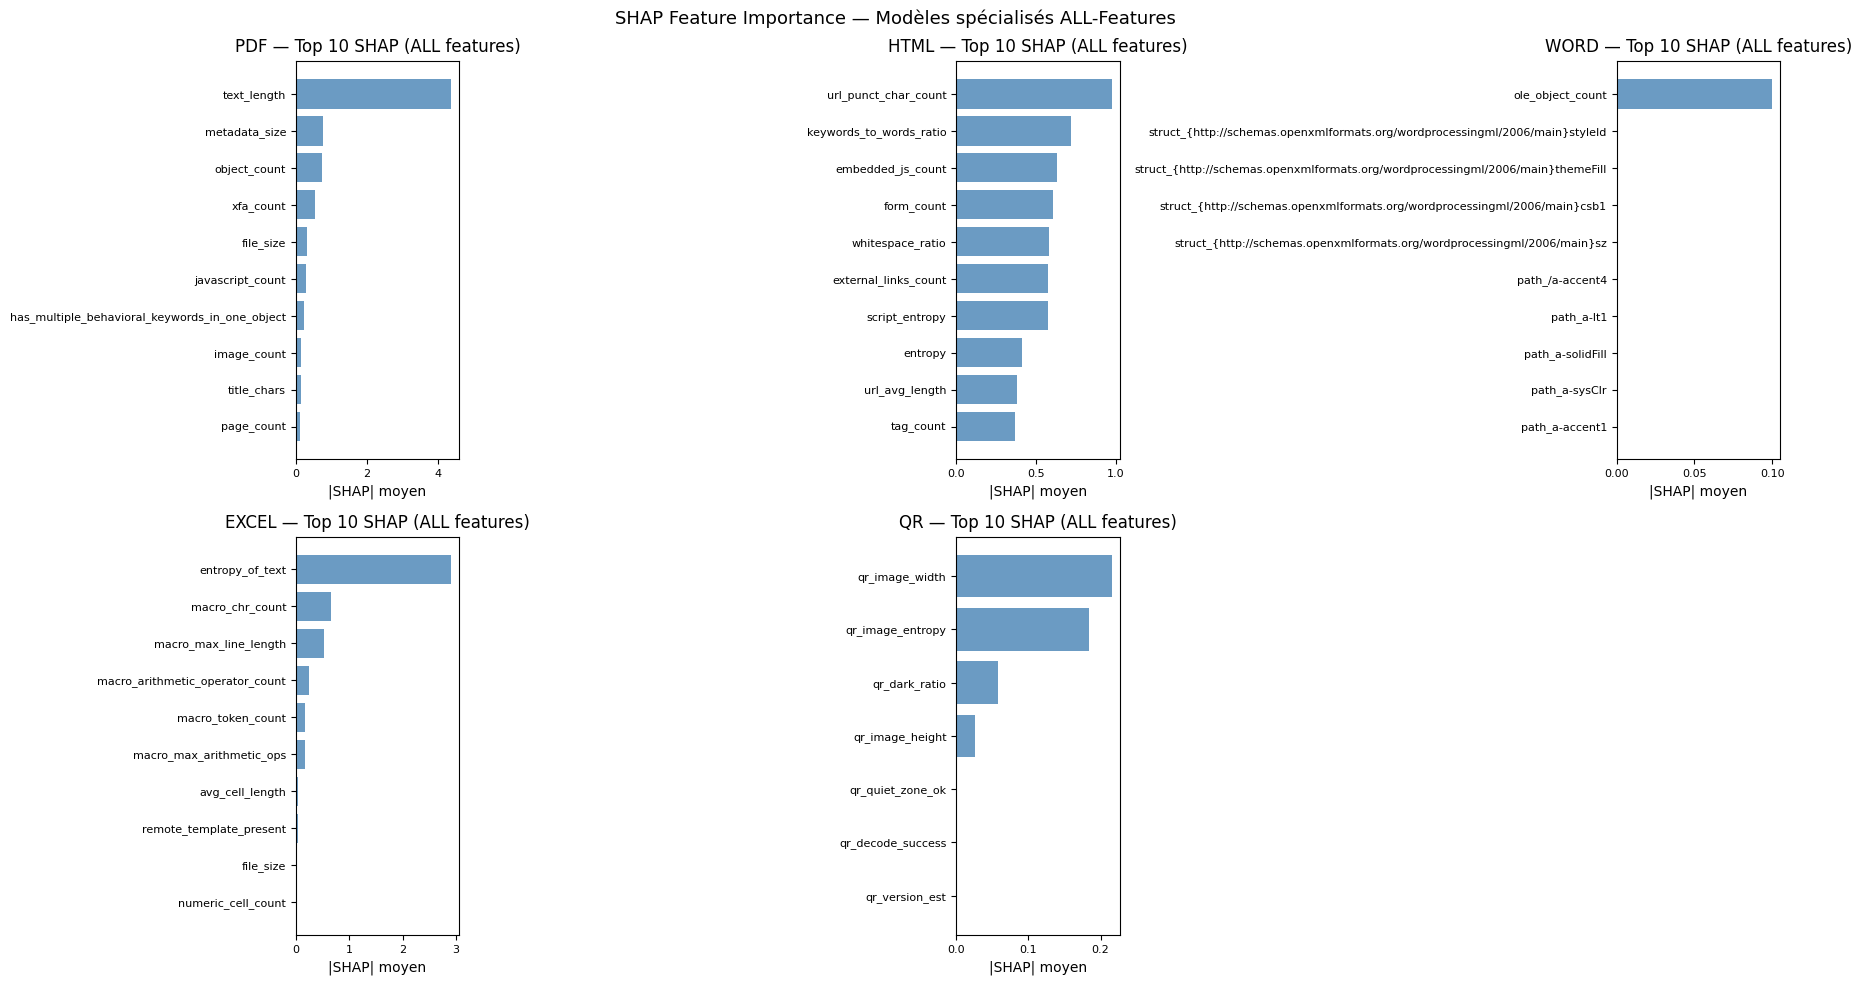

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, fmt in enumerate(models_all.keys()):
    X_tr,y_tr,X_val,y_val,X_te,y_te,feat_names = splits_all[fmt]
    model = models_all[fmt]
    n_exp = min(300, len(X_te))
    
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_te[:n_exp])
    
    mean_shap = np.abs(sv).mean(axis=0)
    top10_idx = np.argsort(mean_shap)[::-1][:10]
    
    ax = axes[i]
    ax.barh([feat_names[j] for j in reversed(top10_idx)],
            [mean_shap[j] for j in reversed(top10_idx)],
            color='steelblue', alpha=0.8)
    ax.set_title(f'{fmt.upper()} — Top 10 SHAP (ALL features)')
    ax.set_xlabel('|SHAP| moyen')
    ax.tick_params(labelsize=8)
    
    print(f"[{fmt}] Top 5 SHAP features :")
    for rank, j in enumerate(top10_idx[:5]):
        print(f"  {rank+1}. {feat_names[j]:45s}  {mean_shap[j]:.4f}")

# Cacher le subplot en trop si nb formats < 6
for j in range(len(models_all), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('SHAP Feature Importance — Modèles spécialisés ALL-Features', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_all_formats.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Sauvegarde

In [15]:
# Modèles spécialisés ALL
for fmt, m in models_all.items():
    joblib.dump(m, OUTPUT_DIR / f'lgbm_all_{fmt}.pkl')
    joblib.dump(scalers_all[fmt], OUTPUT_DIR / f'scaler_all_{fmt}.pkl')
    _, _, _, _, _, _, fn = splits_all[fmt]
    json.dump(fn, open(OUTPUT_DIR / f'features_all_{fmt}.json','w'), indent=2)

# Modèles spécialisés TOP
for fmt, m in models_top.items():
    joblib.dump(m, OUTPUT_DIR / f'lgbm_top_{fmt}.pkl')
    joblib.dump(scalers_top[fmt], OUTPUT_DIR / f'scaler_top_{fmt}.pkl')
    _, _, _, _, _, _, fn = splits_top[fmt]
    json.dump(fn, open(OUTPUT_DIR / f'features_top_{fmt}.json','w'), indent=2)

# Modèle unifié
joblib.dump(model_unified, OUTPUT_DIR / 'lgbm_unified.pkl')
joblib.dump(scalers_uni['unified'], OUTPUT_DIR / 'scaler_unified.pkl')
json.dump(feat_u, open(OUTPUT_DIR / 'features_unified.json','w'), indent=2)

# CNN QR
if qr_cnn_model is not None:
    torch.save(qr_cnn_model.state_dict(), OUTPUT_DIR / 'qr_cnn_final.pt')

# Résumé
summary = {
    'results': all_results,
    'qr_cnn_auc': qr_cnn_auc if qr_cnn_model else None,
    'leakage_removed': LEAKAGE_FEATURES,
}
json.dump(summary, open(OUTPUT_DIR / 'summary_v2.json','w'), indent=2)

print(f"✅ Tout sauvegardé dans : {OUTPUT_DIR.resolve()}")
print(f"   {len(list(OUTPUT_DIR.iterdir()))} fichiers")


✅ Tout sauvegardé dans : C:\Users\karim\Documents\CIC\models_v2
   40 fichiers
